# Bank Marketing Data Mining Project


## 1. Import Libraries


In [42]:
# Import the libraries required for data manipulation,
# visualisation, preprocessing and machine learning.

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Improve the appearance of plots
sns.set_theme(style="whitegrid")

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset


In [43]:
# Load the Bank Marketing dataset
df = pd.read_csv("../data/bank-additional-full.csv", sep=";")

In [44]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Data Understanding

Understanding the structure of the dataset is a fundamental step in the data mining process. This includes identifying the number of observations, data types, and verifying whether missing values are present before any preprocessing is performed.

In [45]:
# Display the number of rows and columns
print(f"Dataset shape: {df.shape}")

Dataset shape: (41188, 21)


In [46]:
# Display all column names
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [47]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [48]:
# Summary statistics for numerical variables
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [49]:
# Summary statistics for categorical variables
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [50]:
# Check for missing (NaN) values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [51]:
# Count duplicated records
duplicates = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 12


In [52]:
# Count the number of 'unknown' values in each categorical column
unknown_counts = (df == "unknown").sum().sort_values(ascending=False)

unknown_counts

default           8597
education         1731
housing            990
loan               990
job                330
marital             80
age                  0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [53]:
# Display the distribution of the target variable
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [54]:
# Display the percentage distribution of the target variable
df["y"].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [55]:
# Percentage distribution of the target variable
(df["y"].value_counts(normalize=True) * 100).round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

In [56]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical variables:")
print(numerical_columns)

print("\nCategorical variables:")
print(categorical_columns)

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


## 4. Exploratory Data Analysis
Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, detect potential anomalies, and generate business insights before data preprocessing and model development.

### 4.1 Target Distribution

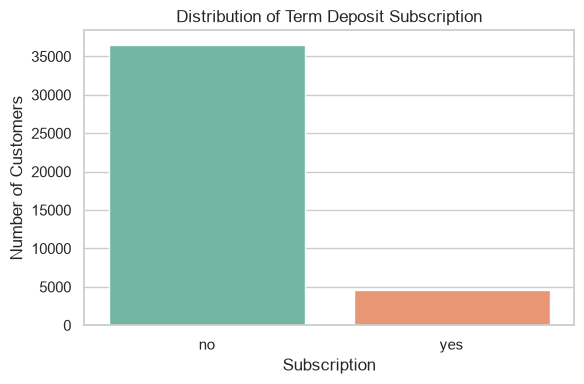

In [57]:
# Create the figure
plt.figure(figsize=(6,4))

# Plot the distribution of the target variable
sns.countplot(
    data=df,
    x="y",
    hue="y",      # avoids future seaborn warnings
    palette="Set2",
    legend=False
)

# Titles
plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 4.2 Age Distribution

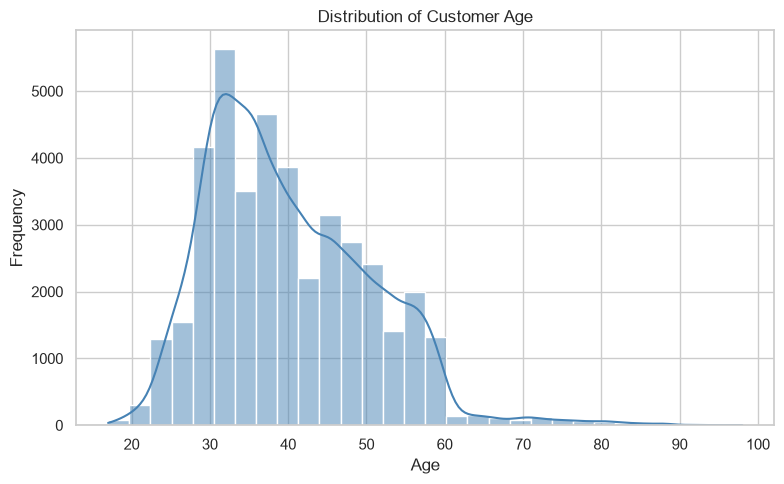

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### 4.3 Job Distribution

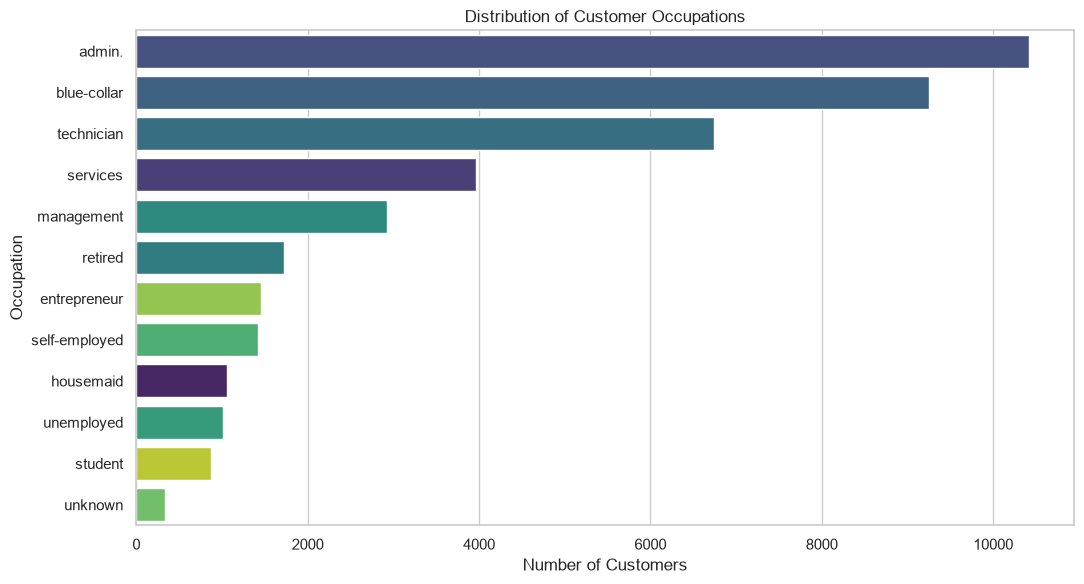

In [59]:
plt.figure(figsize=(11,6))

order = df["job"].value_counts().index

sns.countplot(
    data=df,
    y="job",
    order=order,
    hue="job",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Customer Occupations")
plt.xlabel("Number of Customers")
plt.ylabel("Occupation")

plt.tight_layout()

plt.show()

### 4.4 Education Distribution

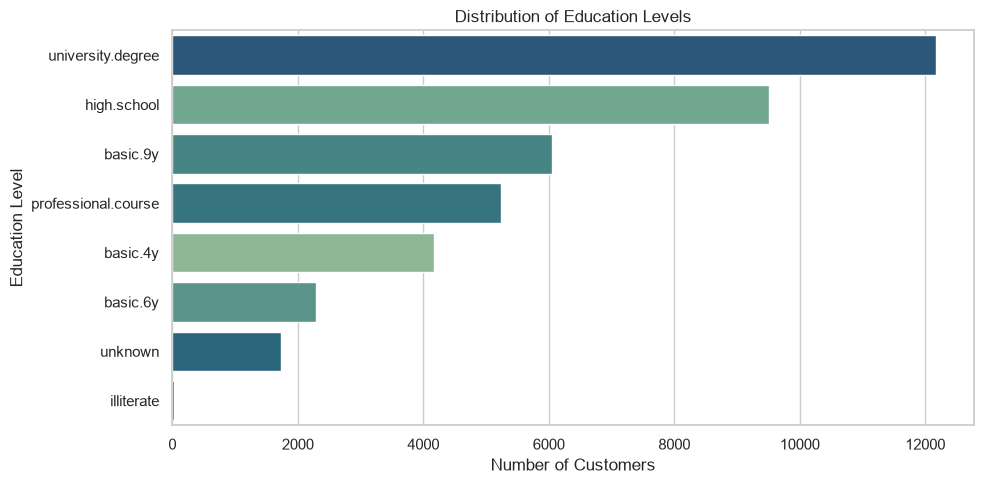

In [60]:
plt.figure(figsize=(10,5))

order = df["education"].value_counts().index

sns.countplot(
    data=df,
    y="education",
    order=order,
    hue="education",
    palette="crest",
    legend=False
)

plt.title("Distribution of Education Levels")
plt.xlabel("Number of Customers")
plt.ylabel("Education Level")

plt.tight_layout()

plt.show()

### 4.5 Subscription Rate by Job

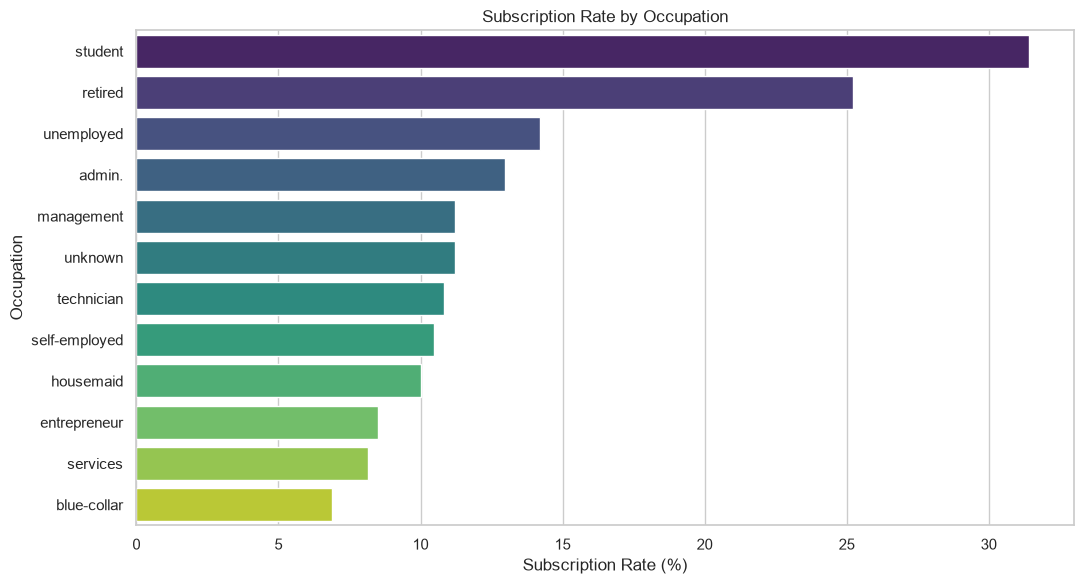

In [61]:
# Calculate the subscription rate for each occupation
job_subscription = (
    df.groupby("job")["y"]
      .value_counts(normalize=True)
      .rename("percentage")
      .mul(100)
      .reset_index()
)

# Keep only customers who subscribed
job_subscription = job_subscription[job_subscription["y"] == "yes"]

# Sort from highest to lowest subscription rate
job_subscription = job_subscription.sort_values(
    by="percentage",
    ascending=False
)

# Plot
plt.figure(figsize=(11,6))

sns.barplot(
    data=job_subscription,
    x="percentage",
    y="job",
    hue="job",
    palette="viridis",
    legend=False
)

plt.title("Subscription Rate by Occupation")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Occupation")

plt.tight_layout()

plt.show()

### 4.6 Subscription Rate by Education

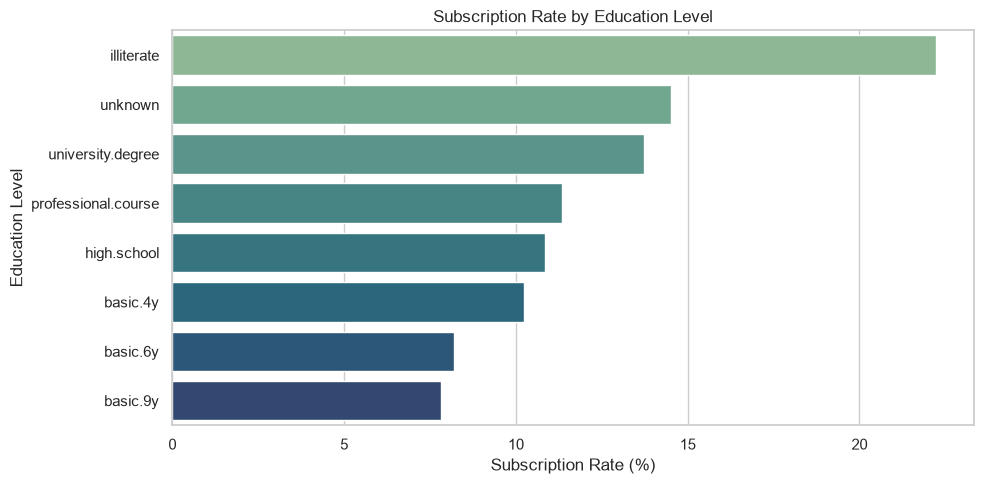

In [62]:
education_subscription = (
    df.groupby("education")["y"]
      .value_counts(normalize=True)
      .rename("percentage")
      .mul(100)
      .reset_index()
)

education_subscription = education_subscription[
    education_subscription["y"] == "yes"
]

education_subscription = education_subscription.sort_values(
    by="percentage",
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=education_subscription,
    x="percentage",
    y="education",
    hue="education",
    palette="crest",
    legend=False
)

plt.title("Subscription Rate by Education Level")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Education Level")

plt.tight_layout()

plt.show()

### 4.7 Subscription Rate by Contact Type

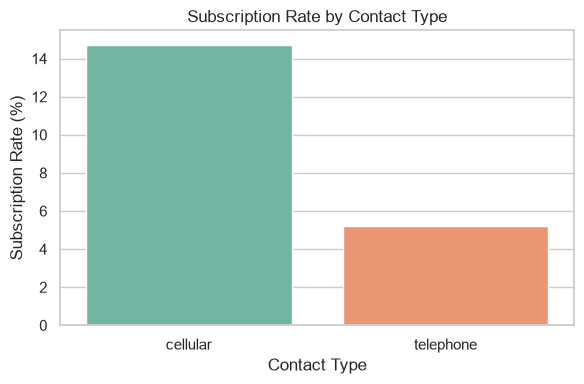

In [63]:
# Calculate subscription rate by contact type
contact_subscription = (
    df.groupby("contact")["y"]
      .value_counts(normalize=True)
      .rename("percentage")
      .mul(100)
      .reset_index()
)

contact_subscription = contact_subscription[
    contact_subscription["y"] == "yes"
]

plt.figure(figsize=(6,4))

sns.barplot(
    data=contact_subscription,
    x="contact",
    y="percentage",
    hue="contact",
    palette="Set2",
    legend=False
)

plt.title("Subscription Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()

plt.show()

### 4.8 Subscription Rate by Month

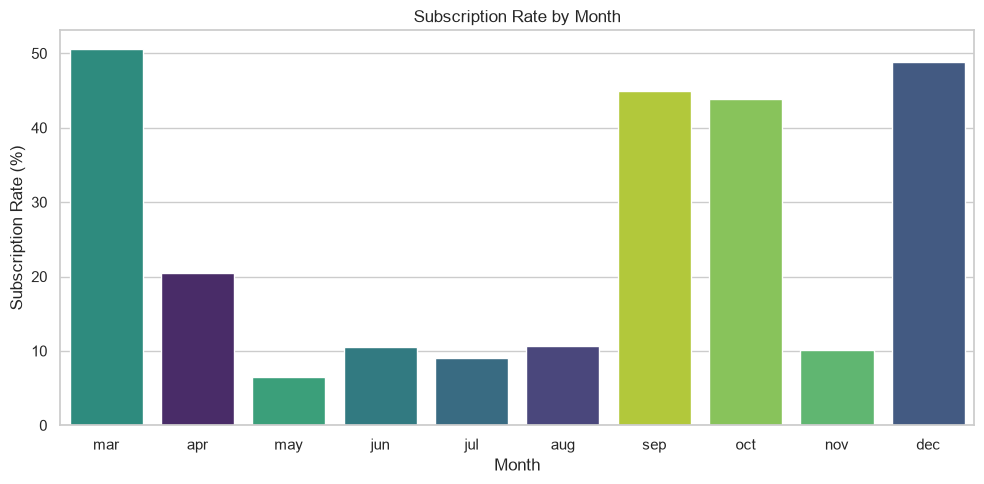

In [64]:
month_subscription = (
    df.groupby("month")["y"]
      .value_counts(normalize=True)
      .rename("percentage")
      .mul(100)
      .reset_index()
)

month_subscription = month_subscription[
    month_subscription["y"] == "yes"
]

month_order = [
    "mar","apr","may","jun","jul","aug",
    "sep","oct","nov","dec"
]

plt.figure(figsize=(10,5))

sns.barplot(
    data=month_subscription,
    x="month",
    y="percentage",
    order=month_order,
    hue="month",
    palette="viridis",
    legend=False
)

plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()

plt.show()

### 4.9 Correlation Heatmap

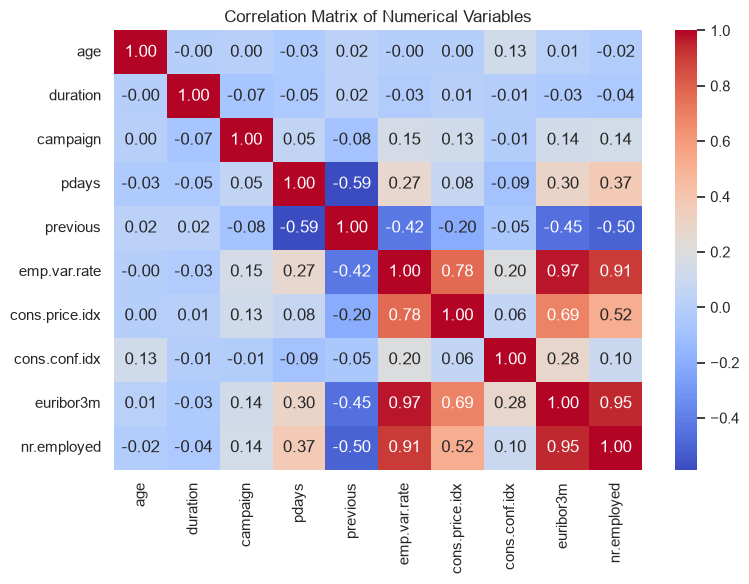

In [65]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()

plt.show()

### 4.10 Boxplots

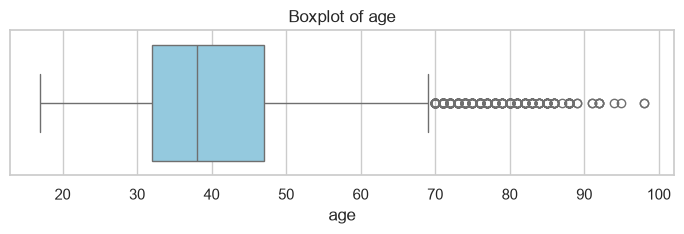

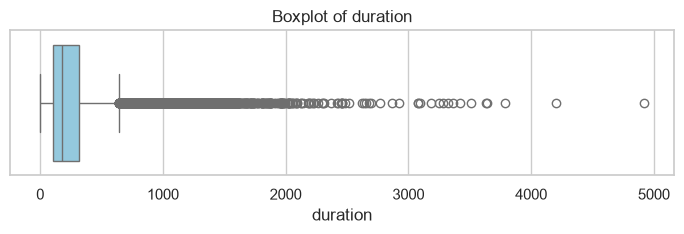

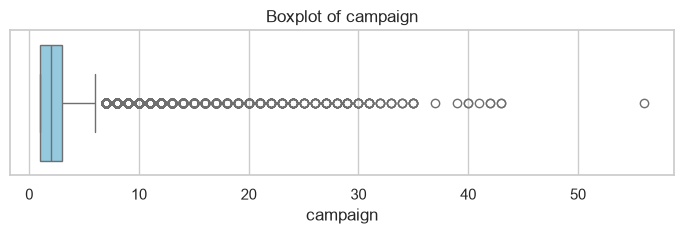

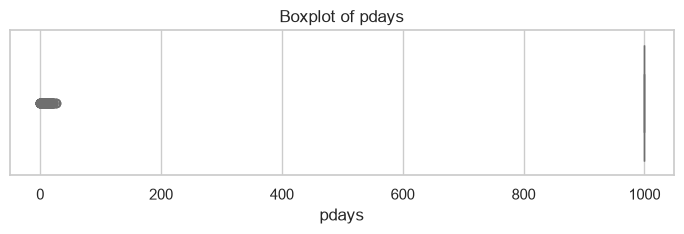

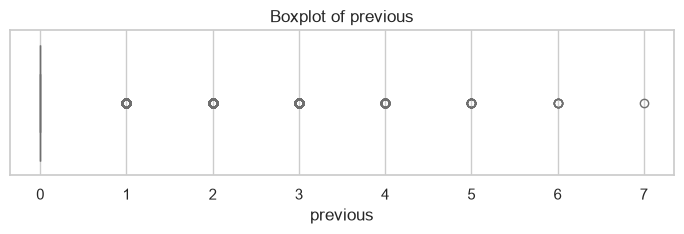

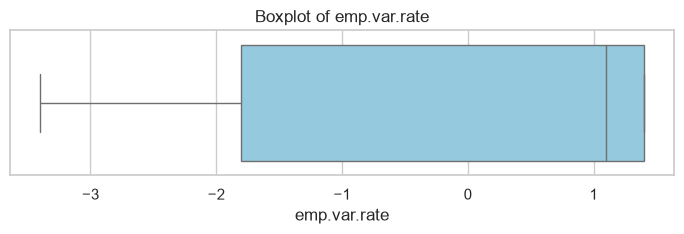

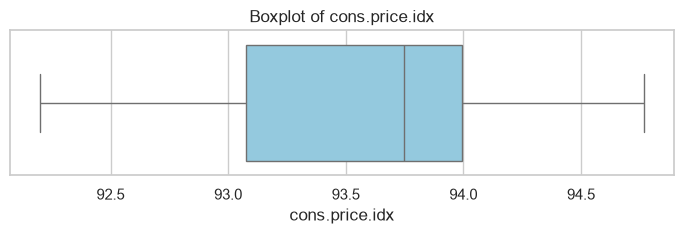

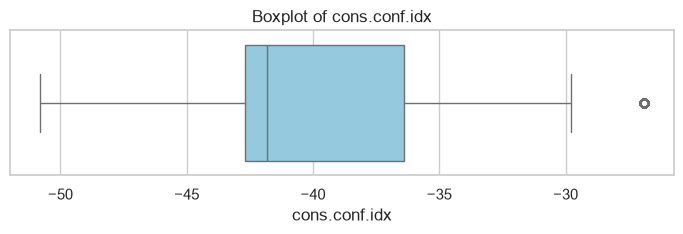

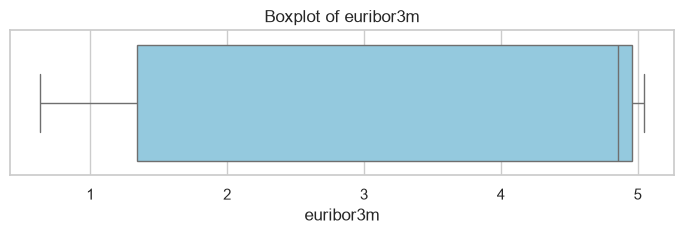

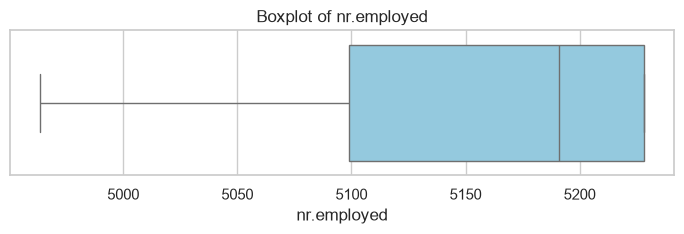

In [66]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_features:
    
    plt.figure(figsize=(7,2.5))
    
    sns.boxplot(
        x=df[column],
        color="skyblue"
    )
    
    plt.title(f"Boxplot of {column}")
    
    plt.tight_layout()
    
    plt.show()

## 5. Data Preprocessing
This section prepares the dataset for predictive modelling by encoding the target variable, removing duplicate records, preventing data leakage, and separating the predictor variables from the target variable.

### 5.1 Create a Working Copy

In [67]:
# Create a copy of the original dataset
df_model = df.copy()


### 5.2 Encode the Target Variable

In [68]:
# Convert the target variable into binary format
df_model["y"] = df_model["y"].map({
    "no": 0,
    "yes": 1
})

### 5.3 Remove Duplicate Records

In [69]:
# Remove duplicate observations
df_model = df_model.drop_duplicates()

print(f"Dataset shape after removing duplicates: {df_model.shape}")

Dataset shape after removing duplicates: (41176, 21)


### 5.4 Remove Data Leakage Variable

In [70]:
# Remove the duration variable to prevent data leakage
df_model = df_model.drop(columns=["duration"])

# duration is only known after the marketing call has ended and therefore cannot be used for realistic prediction.

### 5.5 Separate Features and Target

In [71]:
# Separate predictor variables and target variable
X = df_model.drop(columns=["y"])
y = df_model["y"]

### 5.6 Identify Feature Type

In [72]:
# Identify categorical and numerical variables
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numerical_cols)

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical variables:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 6. Model Preparation
The dataset is prepared for machine learning by splitting it into training and testing subsets and creating preprocessing pipelines for both numerical and categorical variables. This approach helps ensure that data transformations are applied consistently while preventing data leakage.

### 6.1 Dataset Preparation

In [73]:
# Create a working copy of the dataset
df_model = df.copy()

# Encode the target variable
df_model["y"] = df_model["y"].map({
    "no": 0,
    "yes": 1
})

# Remove duplicate observations
df_model = df_model.drop_duplicates()

# Separate predictor variables and target
X = df_model.drop(columns=["y"])
y = df_model["y"]

# Remove the duration variable to prevent data leakage
if "duration" in X.columns:
    X = X.drop(columns=["duration"])

# Identify categorical and numerical variables
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical variables:")
print(categorical_cols)

print("\nNumerical variables:")
print(numerical_cols)

print("\nDataset shape:", X.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True).round(4))

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical variables:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Dataset shape: (41176, 19)

Target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


### 6.2 Train-Test Split

In [74]:
# Split the dataset into training and testing sets
# Stratification preserves the original class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (32940, 19)
Testing set: (8236, 19)

Training target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64

Testing target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


### 6.3 Preprocessing Pipeline

In [75]:
# Create preprocessing pipelines for numerical and categorical variables

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Logistic Regression preprocessor
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Decision Tree preprocessor
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


## 7. Model Development
Two supervised classification models are developed and compared. Logistic Regression is used as an interpretable baseline model, while a Decision Tree is selected to capture nonlinear relationships within the data.


In [76]:
# Create the Logistic Regression pipeline

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

# Train the model
log_reg_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_log = log_reg_pipeline.predict(X_test)
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [77]:
# Create the Decision Tree pipeline

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

# Train the model
tree_pipeline.fit(X_train, y_train)

# Generate predictions
y_pred_tree = tree_pipeline.predict(X_test)
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 8. Model Evaluation
The performance of the Logistic Regression and Decision Tree models is evaluated using multiple classification metrics. Since the dataset is imbalanced, accuracy alone is insufficient; therefore, precision, recall, F1-score, and ROC-AUC are also used to provide a comprehensive comparison.


### 8.1 Classification Reports


In [78]:
# Import the evaluation function used to generate a detailed classification report for each model
from sklearn.metrics import classification_report

# Display the classification report for the Logistic Regression model
print("=" * 60)
print("Logistic Regression Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_log))


# Display the classification report for the Decision Tree model
print("\n" + "=" * 60)
print("Decision Tree Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.65      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236


Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      7308
           1       0.32      0.35      0.33       928

    accuracy                           0.84      8236
   macro avg       0.62      0.63      0.62      8236
weighted avg       0.85      0.84      0.84      8236



### 8.2 Performance Comparison

In [79]:
# Import the evaluation metrics used to compare both models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create a summary table containing the most important
# performance metrics for each model
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree)
    ]

})

# Display all evaluation metrics rounded to four decimal places
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8983,0.6500,0.2101,0.3176,0.8004
1,Decision Tree,0.8411,0.3163,0.3534,0.3338,0.6312


In [80]:
# Sort the models by F1 Score.
# Since the dataset is imbalanced, the F1 Score provides a better overall comparison than accuracy alone.
results.sort_values(
    by="F1 Score",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.8411,0.3163,0.3534,0.3338,0.6312
0,Logistic Regression,0.8983,0.6500,0.2101,0.3176,0.8004


### 8.3 Confusion Matrix Comparison

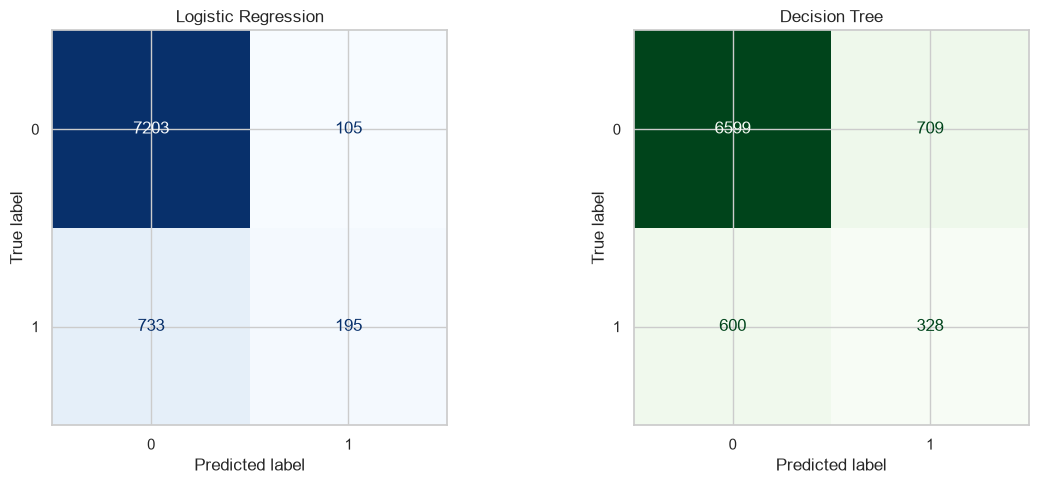

In [81]:
# Import the tools required to visualise confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create two plots side by side for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_log)
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title("Logistic Regression")


# Decision Tree Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tree)
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)

axes[1].set_title("Decision Tree")


# Adjust spacing between the plots
plt.tight_layout()


plt.show()

### 8.4 ROC Curve Comparison

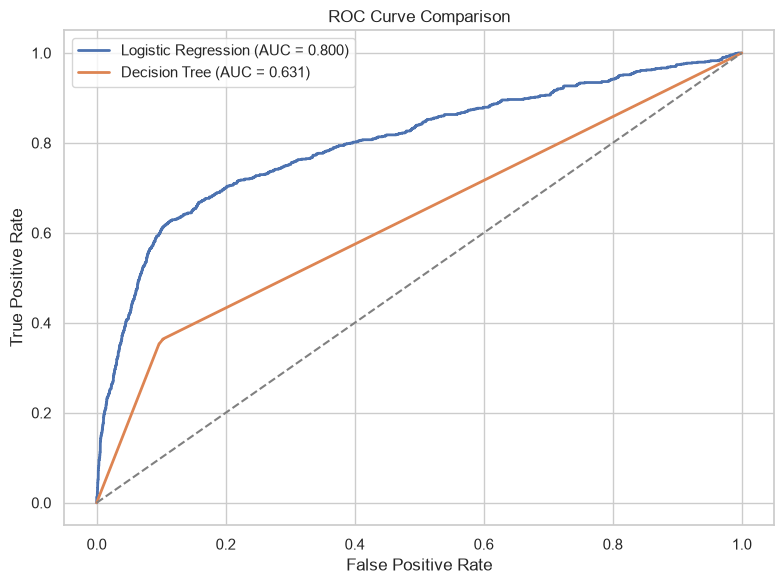

In [82]:
# Import the function used to calculate ROC curve coordinates
from sklearn.metrics import roc_curve

# Calculate the ROC curve for both models
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

# Create the comparison plot
plt.figure(figsize=(8, 6))


# Logistic Regression ROC Curve
plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})"
)


# Decision Tree ROC Curve
plt.plot(
    fpr_tree,
    tpr_tree,
    linewidth=2,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})"
)


# Reference line representing random guessing
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

# Add labels and title
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Display the legend
plt.legend()

# Add a light grid to improve readability
plt.grid(True)

# Ensure elements fit correctly
plt.tight_layout()


plt.show()

### 8.5 Summary of Results

The evaluation metrics indicate that both models have strengths and weaknesses when predicting customer subscription.

Although the Decision Tree achieved a slightly higher Recall and F1-score, Logistic Regression produced substantially higher Precision, Accuracy and ROC-AUC. This suggests that Logistic Regression distinguishes between subscribers and non-subscribers more effectively while generating fewer false positive predictions.

Considering the business objective of supporting targeted marketing campaigns, Logistic Regression was selected as the preferred model because it provides more reliable predictions and reduces unnecessary customer contacts.

## 9. Business Recommendations

Based on the exploratory analysis and model results, the following recommendations are proposed to improve the efficiency of future marketing campaigns:

1. Use the Logistic Regression model to screen customers before campaigns are launched:
    allows the bank to focus on clients with a higher predicted probability of subscribing and reduce wasted contact effort.

2. Prioritize customer segments that showed stronger response patterns in the EDA:
    variables such as job, education, and marital status can help identify groups with higher subscription potential and improve targeting.

3. Focus on the most effective contact strategies observed in the dataset:
   since the campaigns were based on phone calls, the bank should concentrate on contact methods and campaign periods that were historically associated with better conversion outcomes.

4. Monitor model performance and retrain it regularly with new campaign data:
   customer behaviour and economic conditions can change over time, so constant retraining will help maintain prediction quality and keep the model relevant for future campaigns.

## 10. Conclusion
This project analysed the Bank Marketing dataset to predict whether a customer would subscribe to a term deposit. After comparing Logistic Regression and Decision Tree models, Logistic Regression was selected as the preferred model because it provided the strongest overall balance of performance on the test set.

The results show that machine learning can support more efficient campaign targeting by helping the bank focus on customers with a higher probability of subscribing. In practice, this can reduce wasted contacts and improve the effectiveness of future marketing efforts.